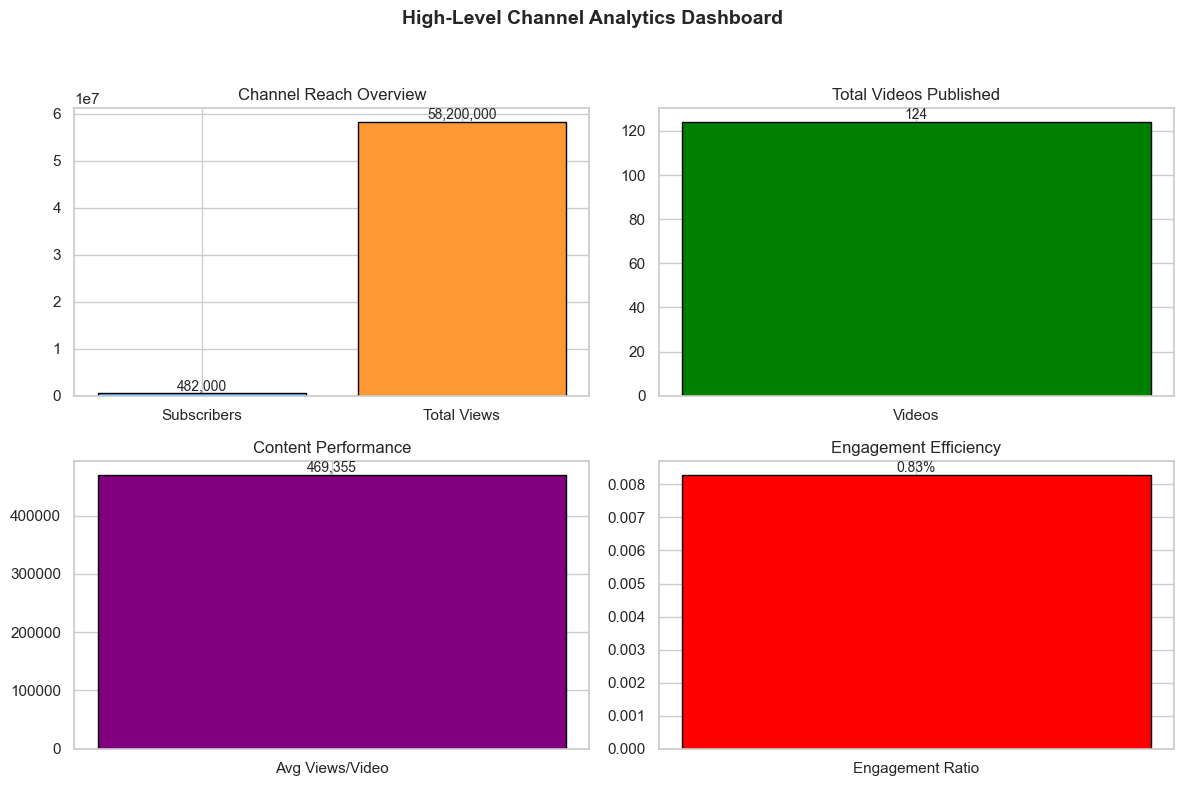

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load channel data
channel_df = pd.read_csv(r"C:\Users\Lenovo\Downloads\sample_channel.csv")

# Extract values
subs = channel_df["subscribers"][0]
views = channel_df["total_views"][0]
videos = channel_df["video_count"][0]

# Derived metrics
avg_views_per_video = views / videos if videos > 0 else 0
engagement_ratio = subs / views if views > 0 else 0

# Set style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Subscribers vs Views
axes[0,0].bar(["Subscribers","Total Views"], [subs, views], 
              color=["#4db8ff","#ff9933"], edgecolor="black")
axes[0,0].set_title("Channel Reach Overview")
for i, val in enumerate([subs, views]):
    axes[0,0].text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=10)

# Video Count
axes[0,1].bar(["Videos"], [videos], color="green", edgecolor="black")
axes[0,1].set_title("Total Videos Published")
axes[0,1].text(0, videos, f"{videos:,}", ha="center", va="bottom", fontsize=10)

# Average Views per Video
axes[1,0].bar(["Avg Views/Video"], [avg_views_per_video], color="purple", edgecolor="black")
axes[1,0].set_title("Content Performance")
axes[1,0].text(0, avg_views_per_video, f"{avg_views_per_video:,.0f}", ha="center", va="bottom", fontsize=10)

# Engagement Ratio
axes[1,1].bar(["Engagement Ratio"], [engagement_ratio], color="red", edgecolor="black")
axes[1,1].set_title("Engagement Efficiency")
axes[1,1].text(0, engagement_ratio, f"{engagement_ratio:.2%}", ha="center", va="bottom", fontsize=10)

plt.suptitle("High-Level Channel Analytics Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


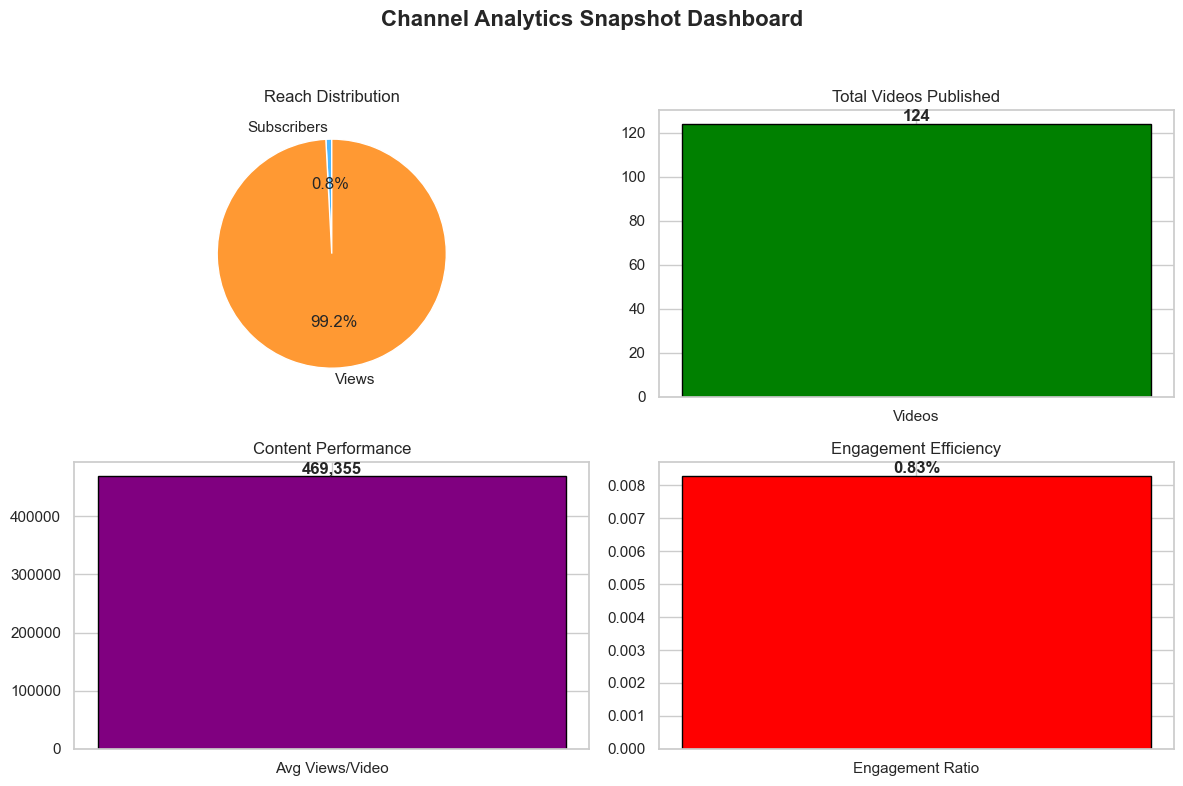

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load channel data
channel_df = pd.read_csv(r"C:\Users\Lenovo\Downloads\sample_channel.csv")

# Extract values
subs = channel_df["subscribers"][0]
views = channel_df["total_views"][0]
videos = channel_df["video_count"][0]

# Derived metrics
avg_views_per_video = views / videos if videos > 0 else 0
engagement_ratio = subs / views if views > 0 else 0

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Donut chart: Subscribers vs Views
axes[0,0].pie([subs, views], labels=["Subscribers","Views"], autopct="%1.1f%%",
              colors=["#4db8ff","#ff9933"], startangle=90, wedgeprops={'edgecolor':'white'})
axes[0,0].set_title("Reach Distribution")

# KPI card: Videos
axes[0,1].bar(["Videos"], [videos], color="green", edgecolor="black")
axes[0,1].set_title("Total Videos Published")
axes[0,1].text(0, videos, f"{videos:,}", ha="center", va="bottom", fontsize=12, fontweight="bold")

# KPI card: Avg Views per Video
axes[1,0].bar(["Avg Views/Video"], [avg_views_per_video], color="purple", edgecolor="black")
axes[1,0].set_title("Content Performance")
axes[1,0].text(0, avg_views_per_video, f"{avg_views_per_video:,.0f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

# KPI card: Engagement Ratio
axes[1,1].bar(["Engagement Ratio"], [engagement_ratio], color="red", edgecolor="black")
axes[1,1].set_title("Engagement Efficiency")
axes[1,1].text(0, engagement_ratio, f"{engagement_ratio:.2%}", ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.suptitle("Channel Analytics Snapshot Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


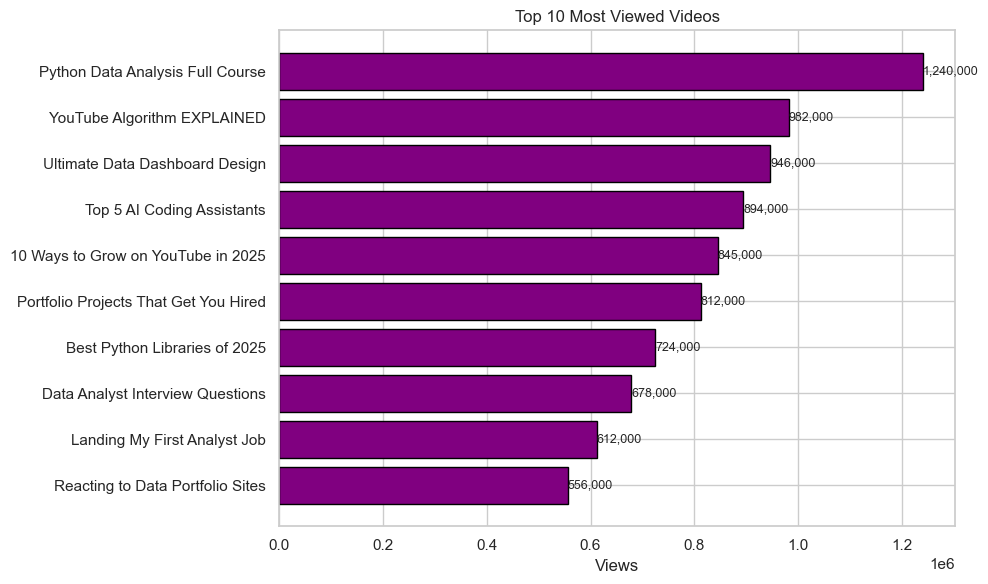

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load video data
videos_df = pd.read_csv(r"C:\Users\Lenovo\Downloads\sample_videos.csv")

# --- Top 10 Most Viewed Videos ---
top_views = videos_df.nlargest(10, "views").sort_values("views", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top_views["title"], top_views["views"], color="purple", edgecolor="black")
for i, val in enumerate(top_views["views"]):
    plt.text(val, i, f"{val:,}", va="center", ha="left", fontsize=9)
plt.title("Top 10 Most Viewed Videos")
plt.xlabel("Views")
plt.tight_layout()
plt.show()


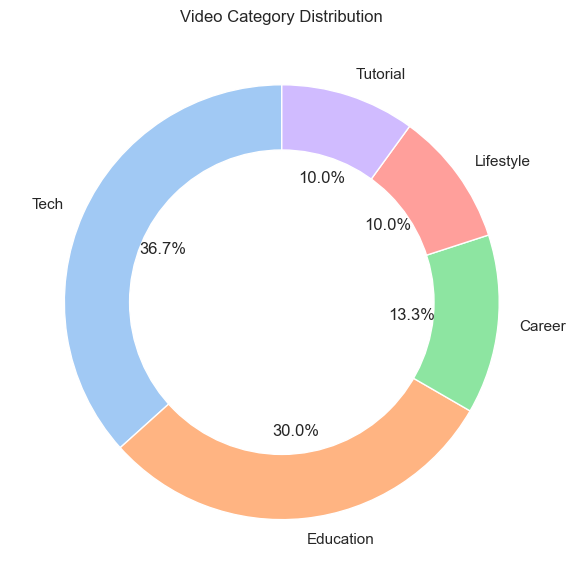

In [38]:
# --- Category Distribution (Donut) ---
plt.figure(figsize=(6,6))
category_counts = videos_df["category"].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"), startangle=90, wedgeprops={'edgecolor':'white'})
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Video Category Distribution")
plt.tight_layout()
plt.show()

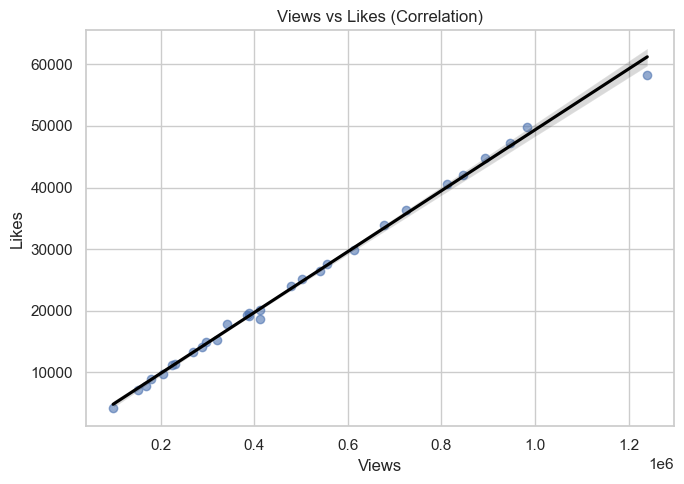

In [39]:
# --- Views vs Likes Scatter with Trendline ---
plt.figure(figsize=(7,5))
sns.regplot(data=videos_df, x="views", y="likes", scatter_kws={'alpha':0.6}, line_kws={'color':'black'})
plt.title("Views vs Likes (Correlation)")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()

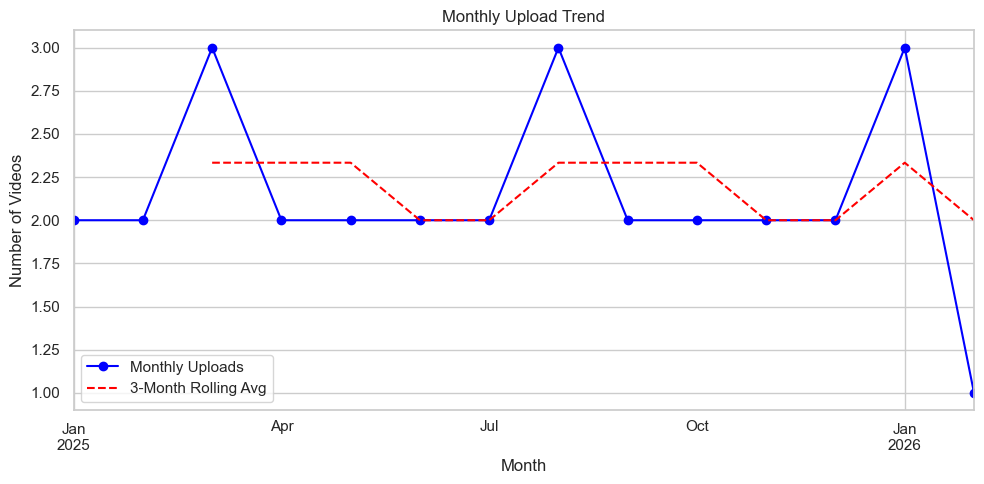

In [40]:
# --- Monthly Upload Trend with Rolling Average ---
videos_df["published_at"] = pd.to_datetime(videos_df["published_at"]).dt.tz_localize(None)
videos_df["month"] = videos_df["published_at"].dt.to_period("M")
monthly_uploads = videos_df.groupby("month").size()

plt.figure(figsize=(10,5))
monthly_uploads.plot(kind="line", marker="o", color="blue", label="Monthly Uploads")
monthly_uploads.rolling(3).mean().plot(color="red", linestyle="--", label="3-Month Rolling Avg")
plt.title("Monthly Upload Trend")
plt.xlabel("Month")
plt.ylabel("Number of Videos")
plt.legend()
plt.tight_layout()
plt.show()